<a href="https://colab.research.google.com/github/miriamamin1213-ux/FinalModels/blob/main/ANNHancock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Number of features: 25

Training samples without SMOTE:
HPV
0    152
1    113
Name: count, dtype: int64
Epoch 50, Train=0.5457, Test=0.5794, BA=0.7060, AUC=0.7894
Epoch 100, Train=0.2347, Test=0.7330, BA=0.6854, AUC=0.7674
Epoch 150, Train=0.0220, Test=1.3911, BA=0.6804, AUC=0.7436
Epoch 200, Train=0.0046, Test=1.7985, BA=0.6754, AUC=0.7436
Epoch 250, Train=0.0020, Test=2.0101, BA=0.6882, AUC=0.7518
Epoch 300, Train=0.0011, Test=2.1622, BA=0.6882, AUC=0.7500
Epoch 350, Train=0.0007, Test=2.2755, BA=0.6882, AUC=0.7509
Epoch 400, Train=0.0005, Test=2.3631, BA=0.6882, AUC=0.7509
Epoch 450, Train=0.0004, Test=2.4370, BA=0.6882, AUC=0.7518
Epoch 500, Train=0.0003, Test=2.4999, BA=0.6882, AUC=0.7518

Best Test Loss = 0.5727 Epoch = 56
Best Test BA   = 0.7495 Epoch = 31
Best Test AUC  = 0.8004 Epoch = 56

ANN Hancock - Best Test Loss
Classification Report

         

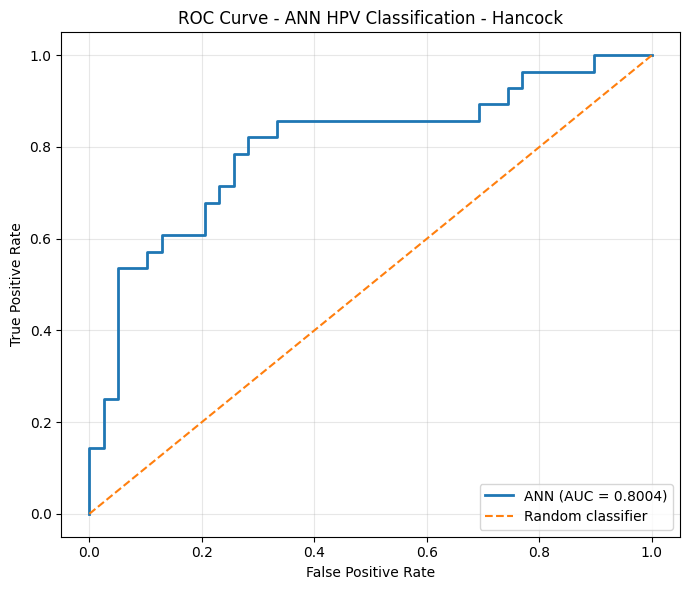

AUC: 0.8004

ANN42_HANCOCK SUMMARY
Architecture : 25-64-32-16-2
Input Features : 25
Learning Rate : 0.001
Optimiser : Adam
Class Weights : Automatic from training set
Encoding : LabelEncoder
SMOTE : No
Split : Stratified 80/20
Preprocessing : Train-only
Scaling : StandardScaler fit on training set
Gradient Clipping : No
Epochs : 500
Best Test Loss Epoch : 56
Best Test BA Epoch : 31
Best Test AUC Epoch : 56
Training Patients : 265
Test Patients : 67
Seed : 42


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, roc_auc_score, f1_score, roc_curve

def seed_everything(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ["PYTHONHASHSEED"]=str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"]=":4096:8"
    torch.use_deterministic_algorithms(True,warn_only=True)
    torch.backends.cudnn.deterministic=True
    torch.backends.cudnn.benchmark=False
    torch.backends.cuda.matmul.allow_tf32=False
    torch.backends.cudnn.allow_tf32=False

SEED=42
seed_everything(SEED)

with open('/content/drive/MyDrive/clinical_data.json') as f:
    clinical=pd.DataFrame(json.load(f))
with open('/content/drive/MyDrive/pathological_data.json') as f:
    pathology=pd.DataFrame(json.load(f))

df=clinical.merge(pathology,on='patient_id',how='inner')
df=df[df['hpv_association_p16'].isin(['positive','negative'])].copy()
df['HPV']=df['hpv_association_p16'].map({'negative':0,'positive':1})

features=['age_at_initial_diagnosis','sex','smoking_status','primarily_metastasis','first_treatment_intent','first_treatment_modality','days_to_first_treatment','adjuvant_treatment_intent','adjuvant_radiotherapy','adjuvant_radiotherapy_modality','adjuvant_systemic_therapy','adjuvant_systemic_therapy_modality','adjuvant_radiochemotherapy','primary_tumor_site','pT_stage','pN_stage','histologic_type','number_of_positive_lymph_nodes','number_of_resected_lymph_nodes','perinodal_invasion','lymphovascular_invasion_L','vascular_invasion_V','perineural_invasion_Pn','resection_status','infiltration_depth_in_mm']
cat_cols=['sex','smoking_status','primarily_metastasis','first_treatment_intent','first_treatment_modality','adjuvant_treatment_intent','adjuvant_radiotherapy','adjuvant_radiotherapy_modality','adjuvant_systemic_therapy','adjuvant_systemic_therapy_modality','adjuvant_radiochemotherapy','primary_tumor_site','pT_stage','pN_stage','histologic_type','perinodal_invasion','lymphovascular_invasion_L','vascular_invasion_V','perineural_invasion_Pn','resection_status']
num_cols=['age_at_initial_diagnosis','days_to_first_treatment','number_of_positive_lymph_nodes','number_of_resected_lymph_nodes','infiltration_depth_in_mm']

X=df[features].copy()
y=df['HPV'].copy()

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=SEED,stratify=y)

for col in cat_cols:
    mode=X_train[col].mode()
    fill_value=mode.iloc[0] if len(mode)>0 else "Unknown"
    X_train[col]=X_train[col].fillna(fill_value)
    X_test[col]=X_test[col].fillna(fill_value)

for col in num_cols:
    median=X_train[col].median()
    X_train[col]=X_train[col].fillna(median)
    X_test[col]=X_test[col].fillna(median)

for col in cat_cols:
    encoder=LabelEncoder()
    X_train[col]=encoder.fit_transform(X_train[col].astype(str))
    known=set(encoder.classes_)
    X_test[col]=X_test[col].astype(str).map(lambda x: encoder.transform([x])[0] if x in known else -1)

n_features=X_train.shape[1]
print("Number of features:",n_features)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

print("\nTraining samples without SMOTE:")
print(pd.Series(y_train).value_counts())

X_train=torch.FloatTensor(X_train)
X_test=torch.FloatTensor(X_test)
y_train=torch.LongTensor(y_train.to_numpy())
y_test=torch.LongTensor(y_test.to_numpy())

class HPVNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1=nn.Linear(n_features,64)
        self.fc2=nn.Linear(64,32)
        self.fc3=nn.Linear(32,16)
        self.fc4=nn.Linear(16,2)
        self.relu=nn.ReLU()
    def forward(self,x):
        x=self.relu(self.fc1(x))
        x=self.relu(self.fc2(x))
        x=self.relu(self.fc3(x))
        return self.fc4(x)

model=HPVNet()
class_counts=np.bincount(y_train.numpy())
class_weights=len(y_train)/(len(class_counts)*class_counts)
class_weights=torch.tensor(class_weights,dtype=torch.float32)
criterion=nn.CrossEntropyLoss(weight=class_weights)
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)
epochs=500

best_test_loss=float("inf")
best_test_ba=-1
best_test_auc=-1
best_loss_epoch=0
best_ba_epoch=0
best_auc_epoch=0

for epoch in range(epochs):
    model.train()
    outputs=model(X_train)
    train_loss=criterion(outputs,y_train)
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_outputs=model(X_test)
        test_loss=criterion(test_outputs,y_test)
        test_probabilities=torch.softmax(test_outputs,dim=1)[:,1]
        test_predicted=torch.argmax(test_outputs,dim=1)

    test_ba=balanced_accuracy_score(y_test.numpy(),test_predicted.numpy())
    test_auc=roc_auc_score(y_test.numpy(),test_probabilities.numpy())

    if test_loss.item()<best_test_loss:
        best_test_loss=test_loss.item()
        best_loss_epoch=epoch+1
        torch.save(model.state_dict(),"best_ann_hancock_loss.pth")

    if test_ba>best_test_ba:
        best_test_ba=test_ba
        best_ba_epoch=epoch+1
        torch.save(model.state_dict(),"best_ann_hancock_ba.pth")

    if test_auc>best_test_auc:
        best_test_auc=test_auc
        best_auc_epoch=epoch+1
        torch.save(model.state_dict(),"best_ann_hancock_auc.pth")

    if (epoch+1)%50==0:
        print(f"Epoch {epoch+1}, Train={train_loss.item():.4f}, Test={test_loss.item():.4f}, BA={test_ba:.4f}, AUC={test_auc:.4f}")

def evaluate_checkpoint(path,name):
    model.load_state_dict(torch.load(path,map_location="cpu"))
    model.eval()
    with torch.no_grad():
        outputs=model(X_test)
        probabilities=torch.softmax(outputs,dim=1)
        predicted=torch.argmax(outputs,dim=1)

    y_true=y_test.numpy()
    y_pred=predicted.numpy()
    y_score=probabilities[:,1].numpy()
    accuracy=(y_pred==y_true).mean()
    bal_acc=balanced_accuracy_score(y_true,y_pred)
    f1=f1_score(y_true,y_pred)
    auc=roc_auc_score(y_true,y_score)

    print("\n====================================")
    print(name)
    print("====================================")
    print("Classification Report\n")
    print(classification_report(y_true,y_pred,digits=4))
    print("Confusion Matrix")
    print(confusion_matrix(y_true,y_pred))
    print(f"Accuracy:            {accuracy:.4f}")
    print(f"Balanced Accuracy:   {bal_acc:.4f}")
    print(f"F1-score:            {f1:.4f}")
    print(f"AUC:                 {auc:.4f}")

    return y_score,auc

print("\nBest Test Loss =",round(best_test_loss,4),"Epoch =",best_loss_epoch)
print("Best Test BA   =",round(best_test_ba,4),"Epoch =",best_ba_epoch)
print("Best Test AUC  =",round(best_test_auc,4),"Epoch =",best_auc_epoch)

prob_loss,auc_loss=evaluate_checkpoint("best_ann_hancock_loss.pth","ANN Hancock - Best Test Loss")
prob_ba,auc_ba=evaluate_checkpoint("best_ann_hancock_ba.pth","ANN Hancock - Best Test Balanced Accuracy")
prob_auc,auc_auc=evaluate_checkpoint("best_ann_hancock_auc.pth","ANN Hancock - Best Test AUC")

model.load_state_dict(torch.load("best_ann_hancock_auc.pth",map_location="cpu"))
model.eval()

with torch.no_grad():
    outputs=model(X_test)
    probabilities=torch.softmax(outputs,dim=1)

y_score=probabilities[:,1].numpy()
fpr,tpr,_=roc_curve(y_test.numpy(),y_score)
auc=roc_auc_score(y_test.numpy(),y_score)

plt.figure(figsize=(7,6))
plt.plot(fpr,tpr,linewidth=2,label=f'ANN (AUC = {auc:.4f})')
plt.plot([0,1],[0,1],linestyle='--',linewidth=1.5,label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ANN HPV Classification - Hancock')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC: {auc:.4f}")

print("\n====================================")
print("ANN42_HANCOCK SUMMARY")
print("====================================")
print("Architecture : 25-64-32-16-2")
print("Input Features :",n_features)
print("Learning Rate : 0.001")
print("Optimiser : Adam")
print("Class Weights : Automatic from training set")
print("Encoding : LabelEncoder")
print("SMOTE : No")
print("Split : Stratified 80/20")
print("Preprocessing : Train-only")
print("Scaling : StandardScaler fit on training set")
print("Gradient Clipping : No")
print("Epochs : 500")
print("Best Test Loss Epoch :",best_loss_epoch)
print("Best Test BA Epoch :",best_ba_epoch)
print("Best Test AUC Epoch :",best_auc_epoch)
print("Training Patients :",len(y_train))
print("Test Patients :",len(y_test))
print("Seed :",SEED)